In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 6
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.major.size'] = 2
plt.rcParams['ytick.major.size'] = 2
%config InlineBackend.figure_format='retina'

import sys
from pathlib import Path
sys.path.append('../')
from utils import *  # key functions for this project

THRESHOLD = 50


# Trajectory example for CTCF (loop 0)

In [2]:
def plot_bool_track(ax, track, color_false, color_true):
    ax.set_ylim(0, 1)
    ax.set_xlim(-0.5, len(track)-0.5)
    for i, bool_value in enumerate(track):
        ax.add_patch(plt.Rectangle((i-0.5, 0), 1, 1,
                               facecolor=color_true if bool_value else color_false,
                               edgecolor="none"))


In [4]:
rep = 15
loop_num = 0
target_frame_duration = 30

delta_t_CTCF = 1  # seconds
sample_every = int(np.round(target_frame_duration / delta_t_CTCF))
actual_frame_duration = delta_t_CTCF * sample_every

actual_loop = load_ctcf_state(loop_num, rep)

traj_0nm = load_trajectory(loop_num, rep, noise=0)
traj_20nm = load_trajectory(loop_num, rep, noise=20)
traj_50nm = load_trajectory(loop_num, rep, noise=50)


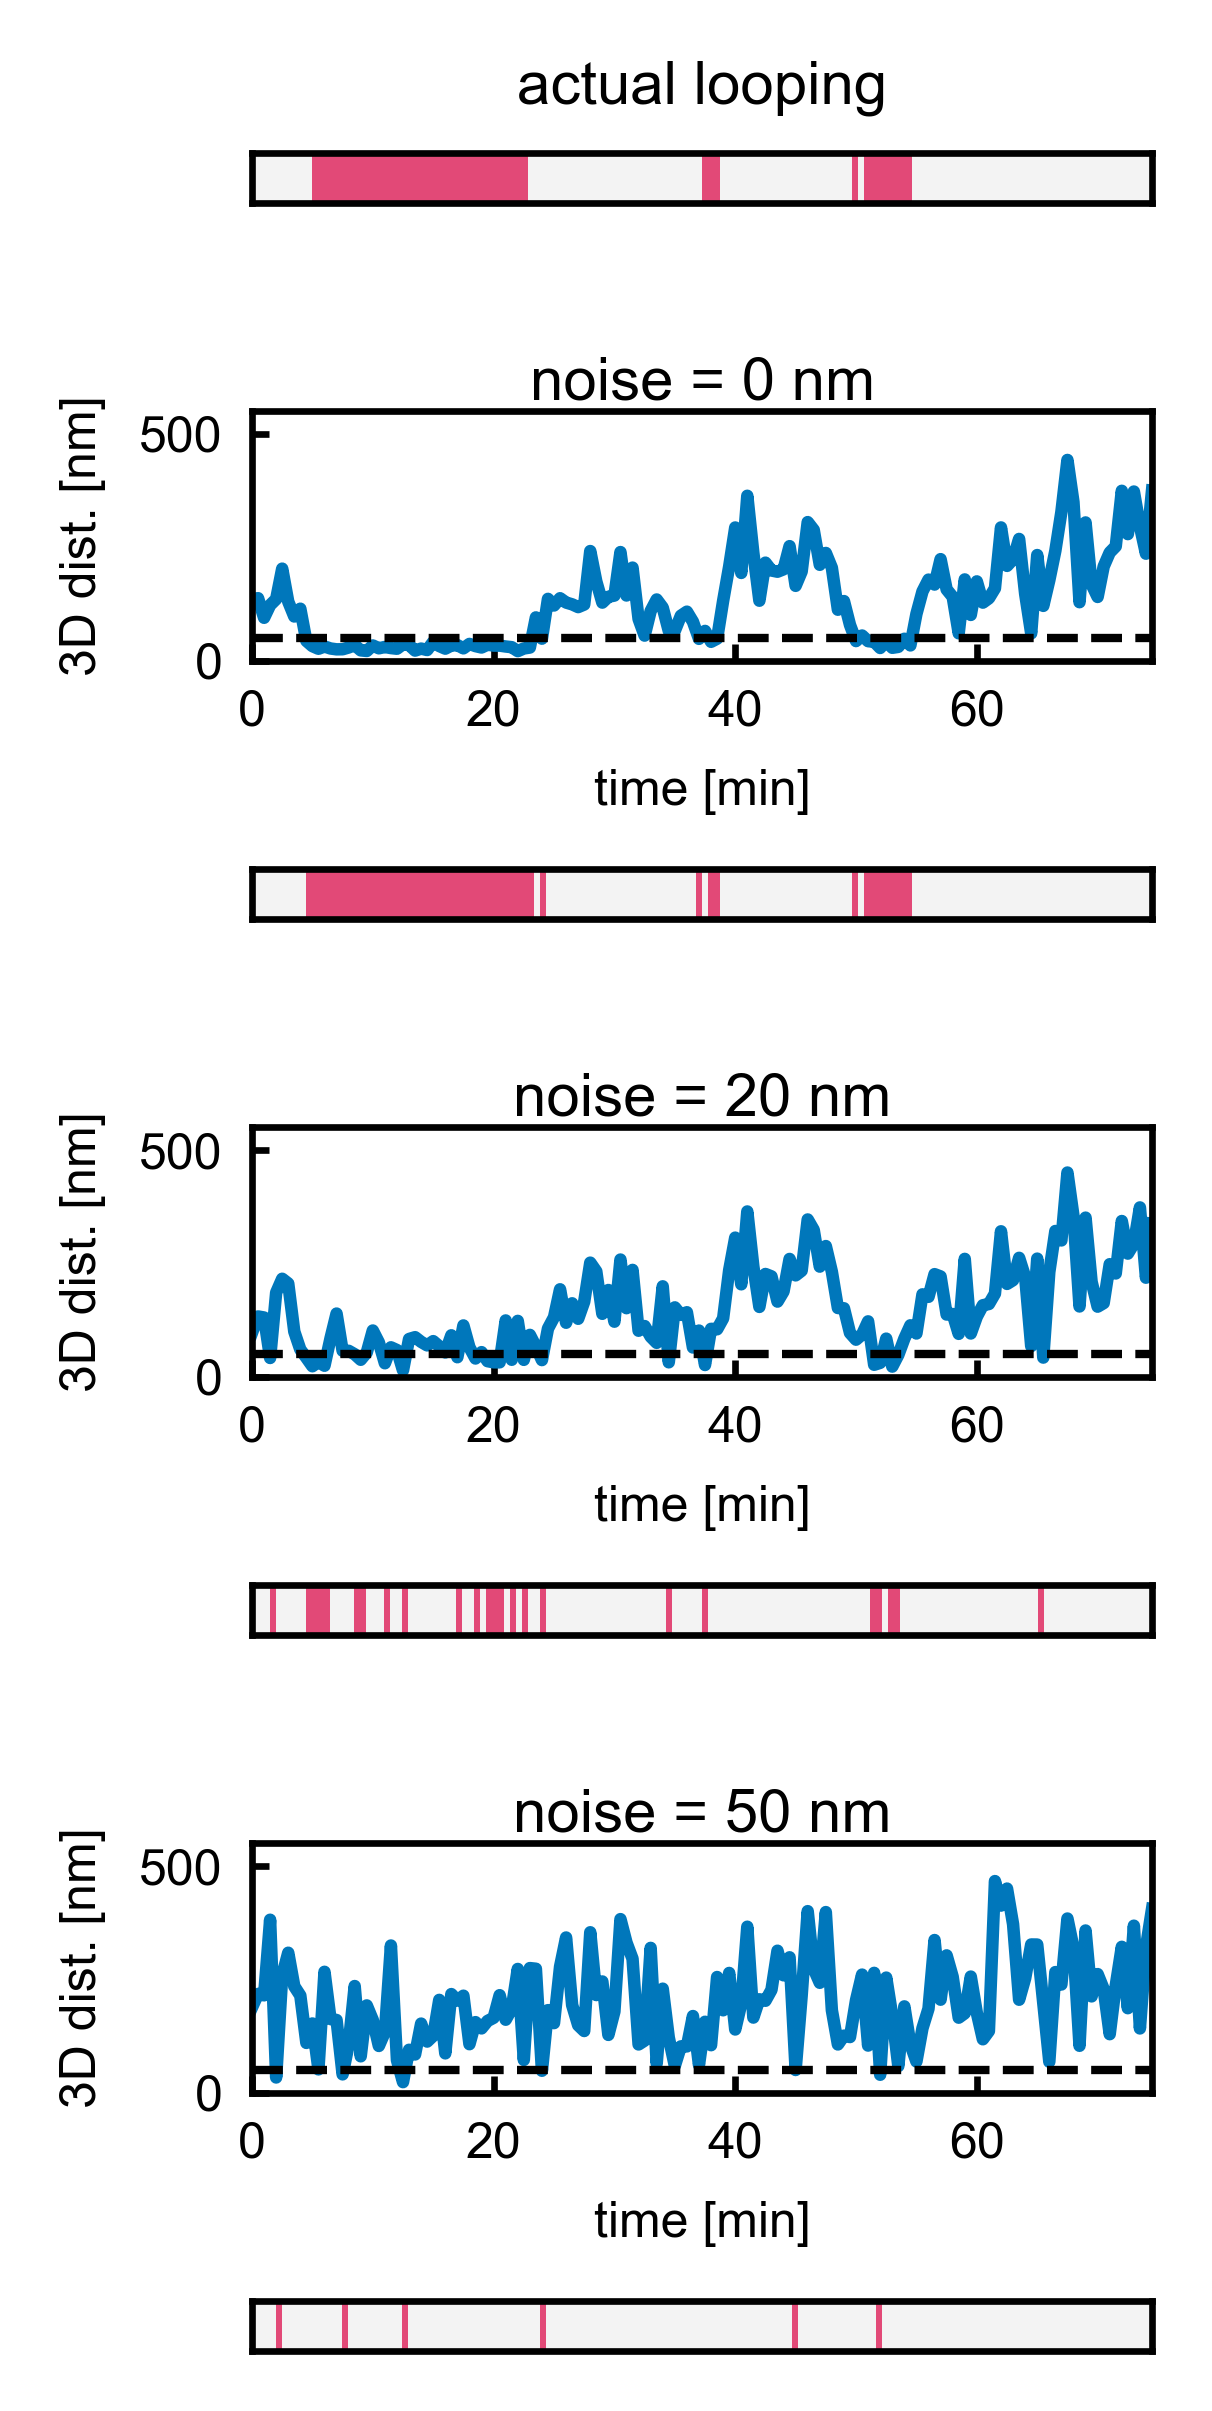

In [5]:
x_start = 0
x_end = 4500
x_range = np.arange(x_start, x_end, sample_every)
x_range_min = np.arange(len(x_range)) * actual_frame_duration / 60

fig, axs = plt.subplots(7, 1, figsize=(2, 4), dpi=300, gridspec_kw={'height_ratios': [1,5,1,5,1,5,1]})

colors = ["#f3f3f3", "#e24977"]

plot_bool_track(axs[0], (actual_loop.iloc[x_range]), colors[0], colors[1])

axs[0].set_title('actual looping')

axs[1].plot(x_range_min, traj_0nm.iloc[x_range], color='#0077bb');
axs[1].set_title('noise = 0 nm', pad=0)

plot_bool_track(axs[2], (traj_0nm.iloc[x_range]<50), colors[0], colors[1])

axs[3].plot(x_range_min, traj_20nm.iloc[x_range], color='#0077bb');
axs[3].set_title('noise = 20 nm', pad=0)

plot_bool_track(axs[4], (traj_20nm.iloc[x_range]<50), colors[0], colors[1])

axs[5].plot(x_range_min, traj_50nm.iloc[x_range], color='#0077bb');
axs[5].set_title('noise = 50 nm', pad=0)

plot_bool_track(axs[6], (traj_50nm.iloc[x_range]<50), colors[0], colors[1])

for i in [1, 3, 5]:
    axs[i].axhline(50, 0, 1, linestyle='--', color='black', linewidth=1)
    axs[i].set_xlim(x_range_min[0], x_range_min[-1])
    axs[i].set_ylim(0, 550)
    axs[i].set_xlabel('time [min]');
    axs[i].set_ylabel('3D dist. [nm]')
for i in [0, 2, 4, 6]:
    axs[i].set_yticks([])
    axs[i].set_xticks([])
    
plt.tight_layout()

plt.savefig('../figure_exports/fig2_CTCF_trajectories.svg')


# Lifetime distribution example for CTCF (loop 0)

In [6]:
loop_num = 0

loop_lifetimes = pd.read_csv(f'../data/CTCF_loops_lifetimes.csv')
    
actual_lifetimes = loop_lifetimes.loc[loop_lifetimes['loop']==loop_num, 'lifetime'] / 60


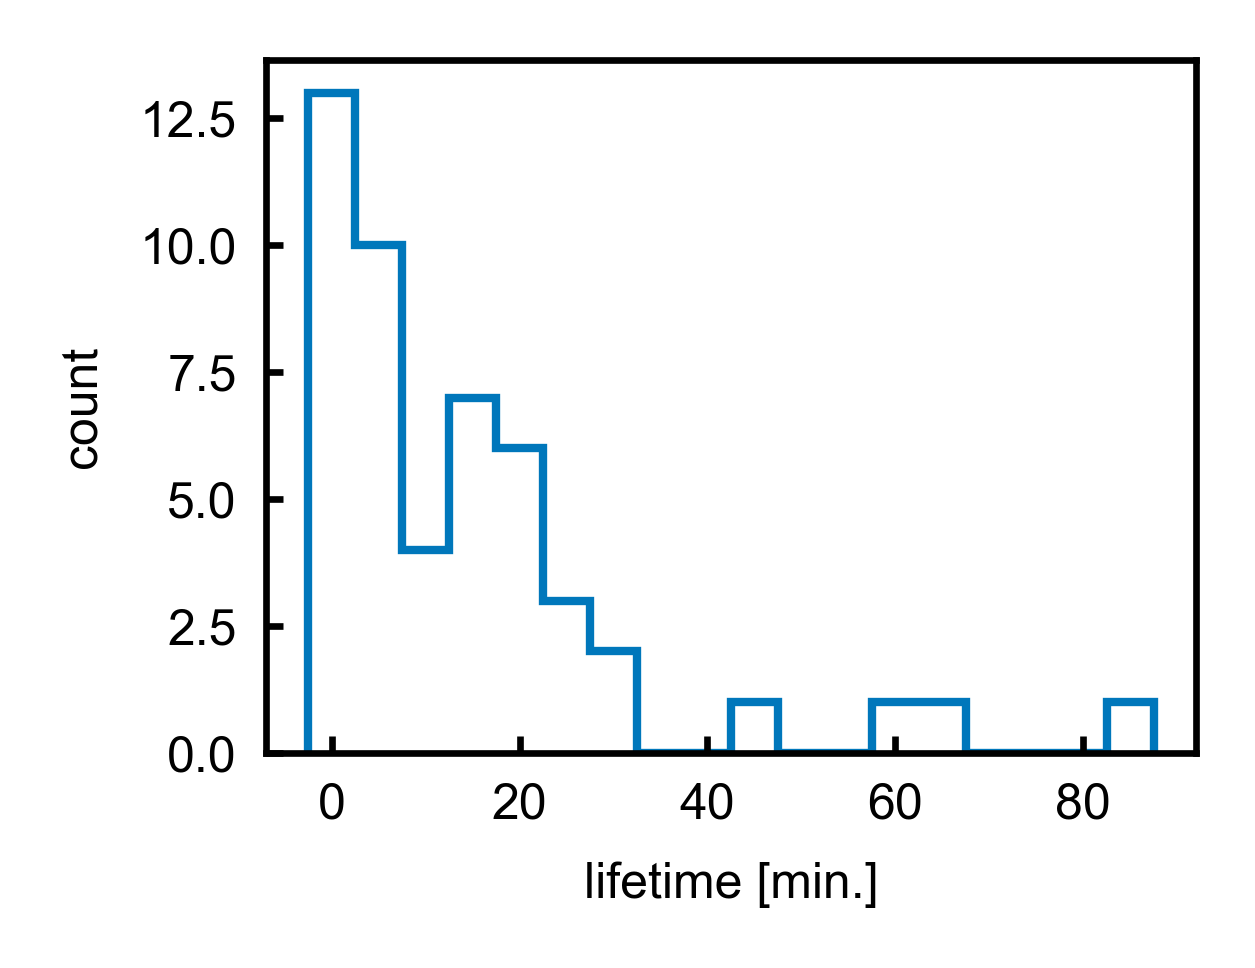

In [7]:
fig, ax = plt.subplots(figsize=(2,1.5), dpi=300)

bin_size = 5
hist, bin_edges = np.histogram(actual_lifetimes, bins=np.arange(-bin_size/2,np.max(actual_lifetimes)+bin_size,bin_size))

ax.stairs(hist, bin_edges, color='#0077bb')
ax.set_xlabel('lifetime [min.]')
ax.set_ylabel('count');

plt.savefig('../figure_exports/fig2_CTCF_lifetime_dist.svg')


# Trajectory example for EP (loop 3)

In [8]:
rep = 10
loop_num = 3
target_frame_duration = 1

delta_t_EP = 0.02  # seconds
sample_every = int(np.round(target_frame_duration / delta_t_EP))
actual_frame_duration = delta_t_EP * sample_every

traj_0nm = load_trajectory(loop_num, rep, noise=0)
traj_20nm = load_trajectory(loop_num, rep, noise=20)
traj_50nm = load_trajectory(loop_num, rep, noise=50)


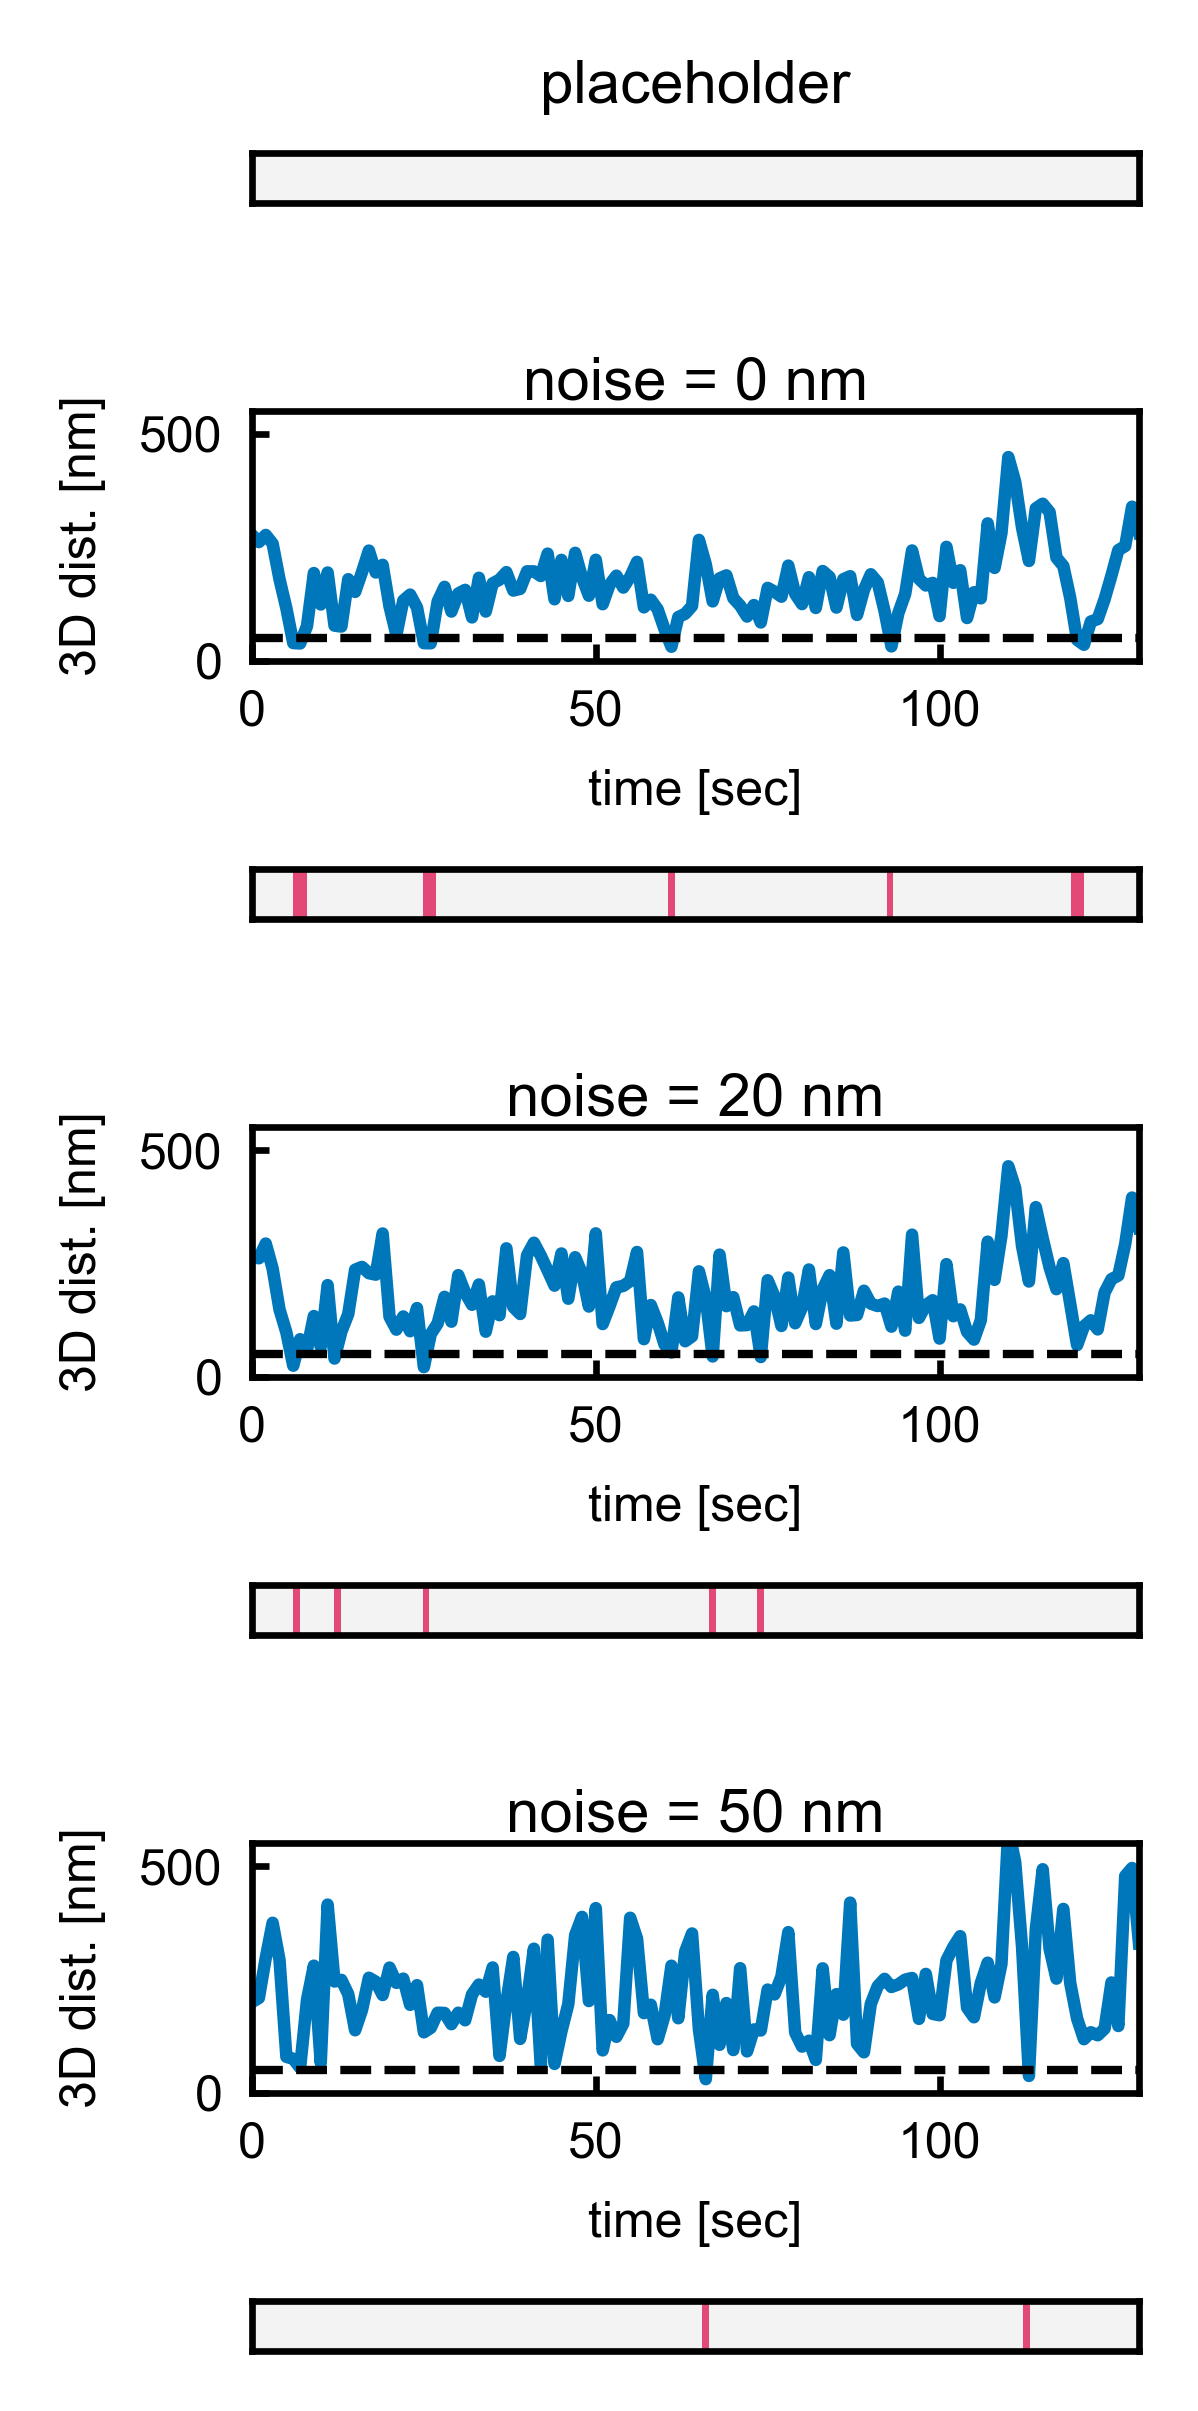

In [9]:
x_start = 5000
x_end = 11500
x_range = np.arange(x_start, x_end, sample_every)
x_range_sec = np.arange(len(x_range)) * actual_frame_duration

fig, axs = plt.subplots(7, 1, figsize=(2, 4), dpi=300, gridspec_kw={'height_ratios': [1,5,1,5,1,5,1]})

colors = ["#f3f3f3", "#e24977"]

plot_bool_track(axs[0], [0]*len(x_range), colors[0], colors[1])

axs[0].set_title('placeholder')

axs[1].plot(x_range_sec, traj_0nm.iloc[x_range], color='#0077bb');
axs[1].set_title('noise = 0 nm', pad=0)

plot_bool_track(axs[2], (traj_0nm.iloc[x_range]<50), colors[0], colors[1])

axs[3].plot(x_range_sec, traj_20nm.iloc[x_range], color='#0077bb');
axs[3].set_title('noise = 20 nm', pad=0)

plot_bool_track(axs[4], (traj_20nm.iloc[x_range]<50), colors[0], colors[1])

axs[5].plot(x_range_sec, traj_50nm.iloc[x_range], color='#0077bb');
axs[5].set_title('noise = 50 nm', pad=0)

plot_bool_track(axs[6], (traj_50nm.iloc[x_range]<50), colors[0], colors[1])

for i in [1, 3, 5]:
    axs[i].axhline(50, 0, 1, linestyle='--', color='black', linewidth=1)
    axs[i].set_xlim(x_range_sec[0], x_range_sec[-1])
    axs[i].set_ylim(0, 550)
    axs[i].set_xlabel('time [sec]');
    axs[i].set_ylabel('3D dist. [nm]')
for i in [0, 2, 4, 6]:
    axs[i].set_yticks([])
    axs[i].set_xticks([])
    
plt.tight_layout()

plt.savefig('../figure_exports/fig2_EP_trajectories.svg')


# Lifetime distribution example for EP loop (loop 3)


In [10]:
EP_loops_lifetime_histograms = pd.read_pickle('../data/EP_loops_lifetime_histograms.pkl')

bin_edges, hist, hist_ns, hist_diff, _ = EP_loops_lifetime_histograms.loc[3]

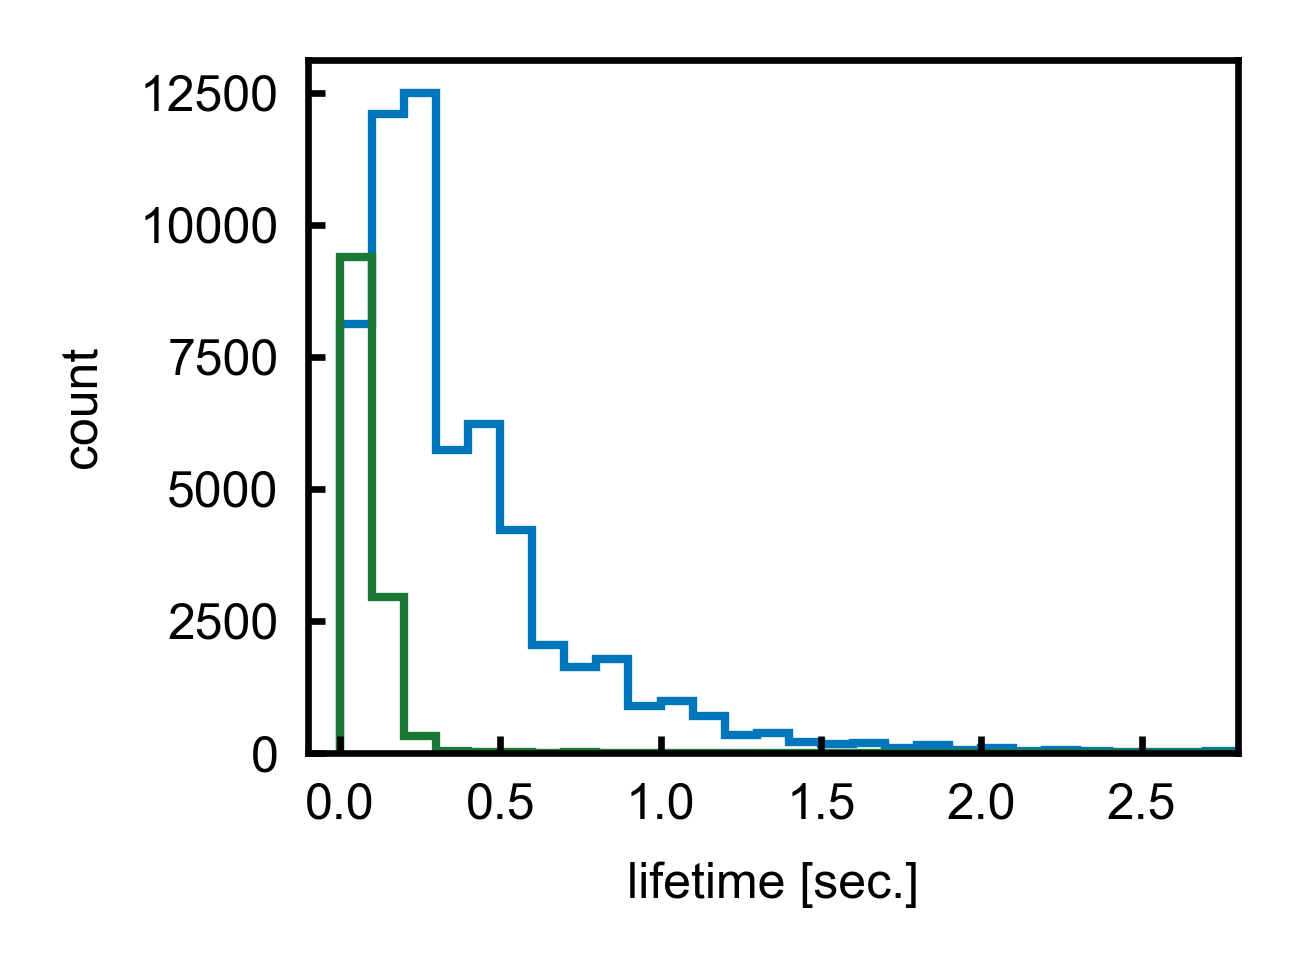

In [11]:
fig, ax = plt.subplots(figsize=(2,1.5), dpi=300)

ax.stairs(hist, bin_edges, color='#0077bb')
ax.stairs(hist_ns, bin_edges, color='#1b7837')
ax.set_xlabel('lifetime [sec.]')
ax.set_ylabel('count');
ax.set_xlim(-0.1,2.8)

plt.savefig('../figure_exports/fig2_EP_lifetime_dist.svg')

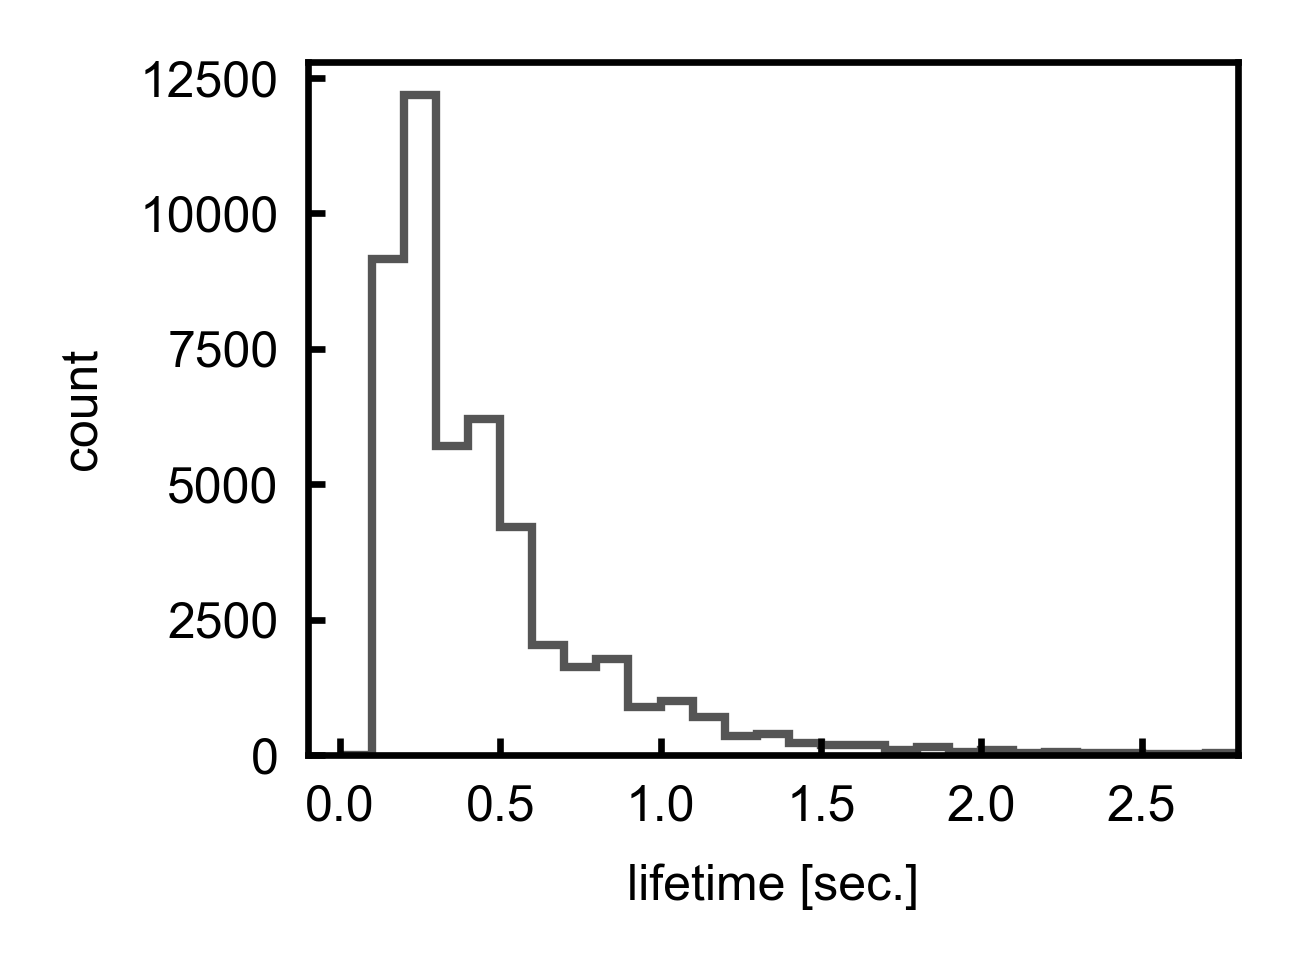

In [12]:
fig, ax = plt.subplots(figsize=(2,1.5), dpi=300)

diff = hist-hist_ns
diff[diff<0] = 0

ax.stairs(diff, bin_edges, color='#555555')
ax.set_xlabel('lifetime [sec.]')
ax.set_ylabel('count');
ax.set_xlim(-0.1,2.8)

plt.savefig('../figure_exports/fig2_EP_lifetime_dist_diff.svg')

# Thresholding cannot predict loop lifetimes


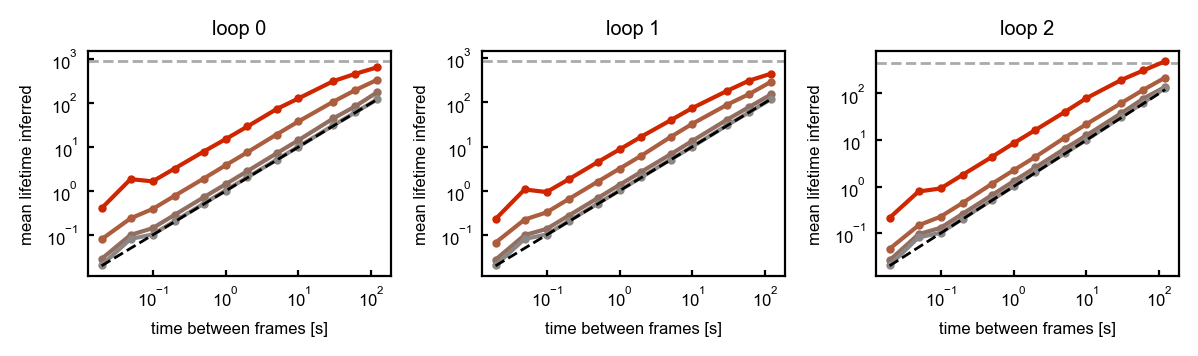

In [34]:
CTCF_loop_lifetimes = pd.read_csv(f'../data/CTCF_loops_lifetimes.csv')
t_under_50nm_CTCF = pd.read_csv(f'../data/CTCF_loops_under_threshold_times_50nm.csv')

CTCF_loops = [0, 1, 2]
dt_arr = np.array([0.02, 0.05, 0.1, 0.2, 0.5, 1, 2, 5, 10, 30, 60, 120])

colors = {0: '#cf2600',
          10: '#ab5d3e',
          20: '#916e60',
          50: '#8c8785'}

fig, axs = plt.subplots(1, 3, figsize=(6, 1.8))
for ax_index, loop_num in enumerate(CTCF_loops):
    actual_lifetimes = CTCF_loop_lifetimes.loc[CTCF_loop_lifetimes['loop']==loop_num, 'lifetime']
    axs[ax_index].axhline(np.mean(actual_lifetimes), 0, 1, color='#aaaaaa', linestyle='--', linewidth=1, zorder=-1)
    for noise in [0, 10, 20, 50]:
        x = []
        y = []
        for dt in dt_arr:
            x.append(dt)
            y.append(np.nanmean(t_under_50nm_CTCF.loc[(t_under_50nm_CTCF['loop']==loop_num) &
                                                (t_under_50nm_CTCF['noise']==noise) &
                                                (t_under_50nm_CTCF['dt']==dt),'time']))
        axs[ax_index].plot(x, y, marker='o', ms=2, label=f'{noise}nm', color=colors[noise])
    handles, labels = axs[ax_index].get_legend_handles_labels()
    axs[ax_index].set_xscale('log')
    axs[ax_index].set_yscale('log')
    axs[ax_index].set_xlabel('time between frames [s]')
    axs[ax_index].set_ylabel('mean lifetime inferred');
    #axs[ax_index].legend(handles=handles, title='noise');
    axs[ax_index].set_title(f'loop {loop_num}')
    axs[ax_index].plot(dt_arr, dt_arr, 0, 1, color='black', linestyle='--', linewidth=1, zorder=10)
    
    axs[ax_index].minorticks_off()

axs[0].set_yticks(10.0**np.array([-1,0,1,2,3]))  # manually adjust first axis ticks

plt.tight_layout()
plt.savefig('../figure_exports/fig2_CTCF_loops_inferred_lifetimes.svg')


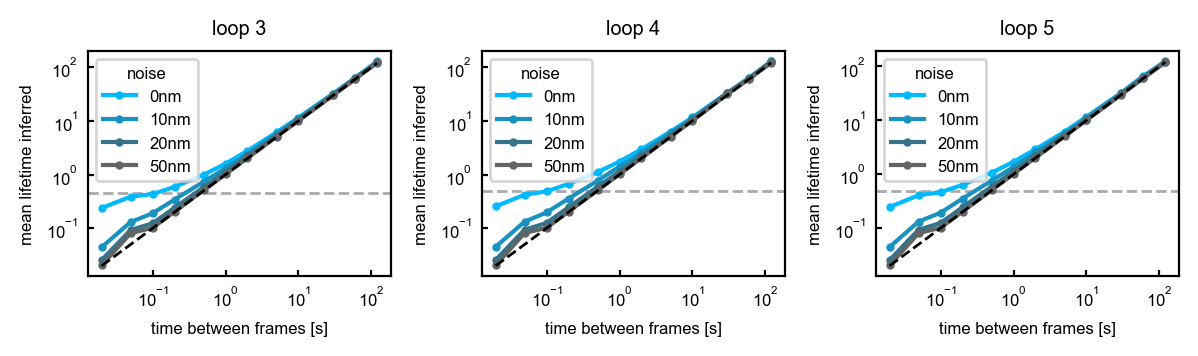

In [10]:
EP_loops_lifetime_histograms = pd.read_pickle('../data/EP_loops_lifetime_histograms.pkl')
t_under_50nm_EP = pd.read_csv(f'../data/EP_loops_under_threshold_times_50nm.csv')

EP_loops = [3, 4, 5]
dt_arr = np.array([0.02, 0.05, 0.1, 0.2, 0.5, 1, 2, 5, 10, 30, 60, 120])

colors = {0: '#00b9ff',
          10: '#1992bf',
          20: '#34738a',
          50: '#626566'}

fig, axs = plt.subplots(1, 3, figsize=(6, 1.8))
for ax_index, loop_num in enumerate(EP_loops):
    axs[ax_index].axhline(EP_loops_lifetime_histograms.loc[loop_num,'mean'], 0, 1, color='#aaaaaa', linestyle='--', linewidth=1, zorder=-1)
    for noise in [0, 10, 20, 50]:
        x = []
        y = []
        for dt in dt_arr:
            x.append(dt)
            y.append(np.nanmean(t_under_50nm_EP.loc[(t_under_50nm_EP['loop']==loop_num) &
                                                    (t_under_50nm_EP['noise']==noise) &
                                                    (t_under_50nm_EP['dt']==dt),'time']))
        axs[ax_index].plot(x, y, marker='o', ms=2, label=f'{noise}nm', color=colors[noise])
    handles, labels = axs[ax_index].get_legend_handles_labels()
    axs[ax_index].set_xscale('log')
    axs[ax_index].set_yscale('log')
    axs[ax_index].set_xlabel('time between frames [s]')
    axs[ax_index].set_ylabel('mean lifetime inferred');
    axs[ax_index].legend(handles=handles, title='noise');
    axs[ax_index].set_title(f'loop {loop_num}')
    axs[ax_index].plot(dt_arr, dt_arr, 0, 1, color='black', linestyle='--', linewidth=1, zorder=10)

    axs[ax_index].minorticks_off()

plt.tight_layout()
plt.savefig('../figure_exports/fig2_EP_loops_inferred_lifetimes.svg')
